In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('primer1.jpg', cv2.IMREAD_GRAYSCALE)
marker = cv2.erode(img, np.ones((15,15), np.uint8), iterations=1)
mask = img

kernel = np.ones((3,3), np.uint8)


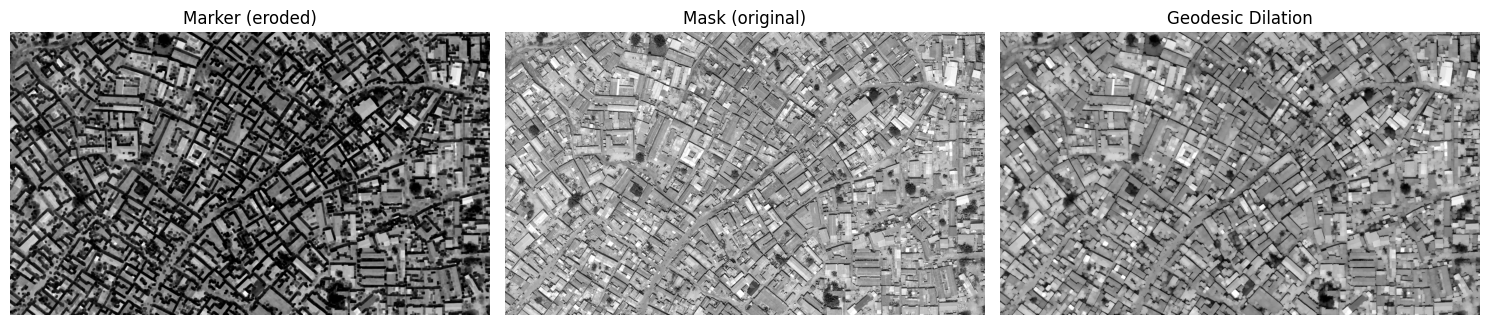

In [2]:
geodesic_dil = marker.copy()
for i in range(10):
    dilated = cv2.dilate(geodesic_dil, kernel, iterations=1)
    geodesic_dil = cv2.min(dilated, mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(marker, cmap='gray')
axes[0].set_title('Marker (eroded)')
axes[0].axis('off')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask (original)')
axes[1].axis('off')
axes[2].imshow(geodesic_dil, cmap='gray')
axes[2].set_title('Geodesic Dilation')
axes[2].axis('off')
plt.tight_layout()
plt.show()


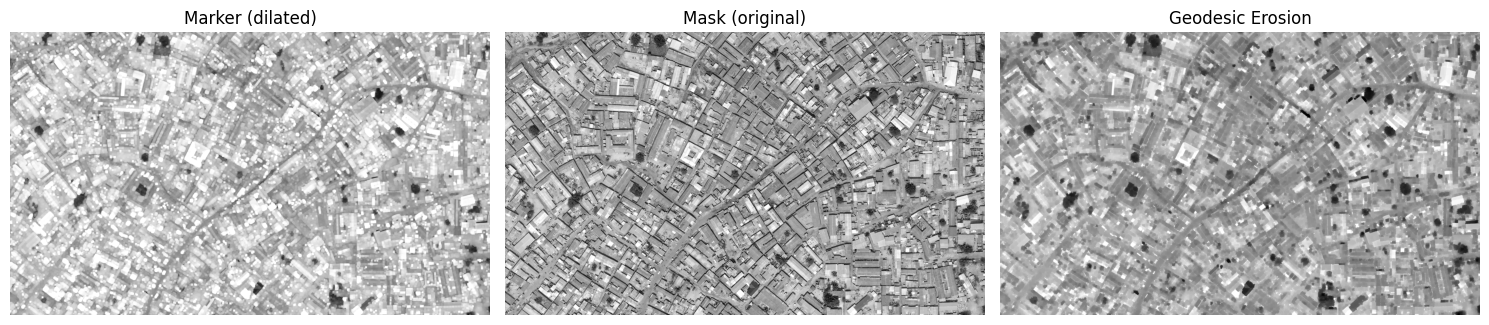

In [3]:
marker2 = cv2.dilate(img, np.ones((15,15), np.uint8), iterations=1)
geodesic_ero = marker2.copy()
for i in range(10):
    eroded = cv2.erode(geodesic_ero, kernel, iterations=1)
    geodesic_ero = cv2.max(eroded, mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(marker2, cmap='gray')
axes[0].set_title('Marker (dilated)')
axes[0].axis('off')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask (original)')
axes[1].axis('off')
axes[2].imshow(geodesic_ero, cmap='gray')
axes[2].set_title('Geodesic Erosion')
axes[2].axis('off')
plt.tight_layout()
plt.show()


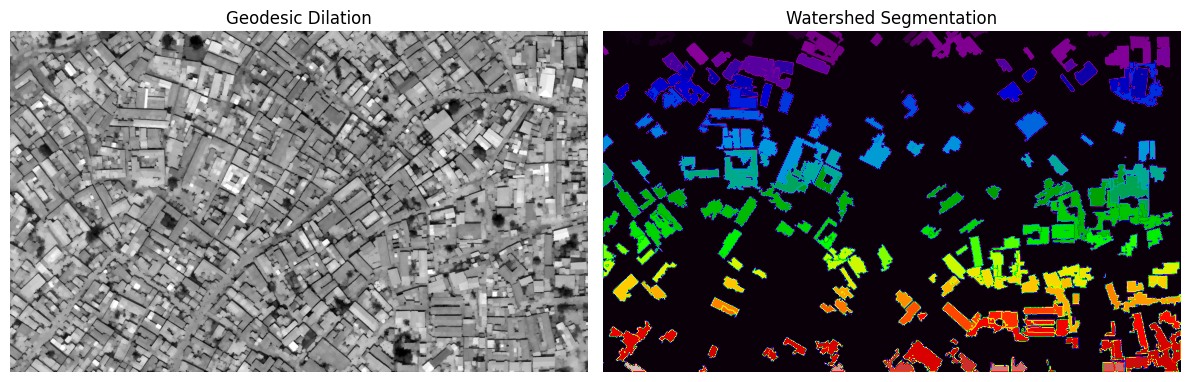

In [4]:
_, thresh = cv2.threshold(geodesic_dil, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
dist_transform = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(thresh, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_color, markers)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(geodesic_dil, cmap='gray')
axes[0].set_title('Geodesic Dilation')
axes[0].axis('off')
axes[1].imshow(markers, cmap='nipy_spectral')
axes[1].set_title('Watershed Segmentation')
axes[1].axis('off')
plt.tight_layout()
plt.show()
